# 🚀 Modèles Avancés et Optimisation

## Objectif
Tester des modèles avancés pour améliorer les performances:
- Random Forest
- LightGBM
- Hyperparameter tuning
- Ensemble methods
- Fine-tuning de Transformers (bonus)

In [1]:
# Imports
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Modules locaux
from src.data_loader import load_training_data, load_test_data, save_submission
from src.preprocessing import extract_full_text
from src.models import LogisticRegressionModel, RandomForestModel
from src.evaluation import evaluate_model, plot_confusion_matrix, plot_roc_curve
from src.utils import load_config

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("✓ Imports réussis")

✓ Imports réussis


## 1. Chargement et Préparation

In [2]:
# Charger config
config = load_config('../config/config.json')
print("✓ Configuration chargée")

# Charger données (utiliser load_jsonl pour avoir le DataFrame complet)
print("\n📥 Chargement des données...")
from src.data_loader import load_jsonl

df_train = load_jsonl('../data/train.jsonl')
df_test = load_jsonl('../data/kaggle_test.jsonl')

# Extraire texte
df_train['full_text'] = df_train.apply(extract_full_text, axis=1)
df_test['full_text'] = df_test.apply(extract_full_text, axis=1)

# Agréger par utilisateur
train_grouped = df_train.groupby('challenge_id').agg({
    'full_text': lambda x: ' '.join(x.astype(str)),
    'label': 'first'
}).reset_index()

test_grouped = df_test.groupby('challenge_id').agg({
    'full_text': lambda x: ' '.join(x.astype(str))
}).reset_index()

X_train = train_grouped['full_text']
y_train = train_grouped['label']
X_test = test_grouped['full_text']
test_ids = test_grouped['challenge_id']

print(f"✓ Train: {len(X_train)} utilisateurs")
print(f"✓ Test: {len(X_test)} utilisateurs")

✓ Configuration chargée

📥 Chargement des données...
✓ Train: 154914 utilisateurs
✓ Test: 103380 utilisateurs
✓ Train: 154914 utilisateurs
✓ Test: 103380 utilisateurs


## 1.5 Feature Engineering Avancé 🔧

Extraction de features textuelles et numériques pour améliorer les modèles

In [3]:
import re

def extract_text_features(text):
    """
    Extrait des features textuelles avancées d'un tweet.
    Basé sur les recommandations de la recherche pour identifier les influenceurs.
    """
    if pd.isna(text):
        text = ""
    
    features = {}
    
    # Longueur du texte
    features['text_length'] = len(text)
    features['word_count'] = len(text.split())
    
    # Comptage des éléments caractéristiques
    features['hashtag_count'] = len(re.findall(r'#\w+', text))
    features['mention_count'] = len(re.findall(r'@\w+', text))
    features['url_count'] = len(re.findall(r'http[s]?://\S+', text))
    features['emoji_count'] = len(re.findall(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF]', text))
    
    # Style d'écriture (influenceurs utilisent souvent plus de majuscules)
    features['uppercase_count'] = sum(1 for c in text if c.isupper())
    features['uppercase_ratio'] = features['uppercase_count'] / len(text) if len(text) > 0 else 0
    
    # Ponctuation (! et ? souvent utilisés pour engager)
    features['exclamation_count'] = text.count('!')
    features['question_count'] = text.count('?')
    
    # Nombres (les influenceurs mentionnent souvent des stats)
    features['number_count'] = len(re.findall(r'\d+', text))
    
    return features

# Appliquer l'extraction de features sur les données brutes (avant agrégation)
print("📊 Extraction des features textuelles...")

# Pour train
text_features_train = df_train['full_text'].apply(extract_text_features)
text_features_df_train = pd.DataFrame(text_features_train.tolist())

# Ajouter les features au dataframe
df_train_enriched = pd.concat([df_train, text_features_df_train], axis=1)

# Pour test
text_features_test = df_test['full_text'].apply(extract_text_features)
text_features_df_test = pd.DataFrame(text_features_test.tolist())
df_test_enriched = pd.concat([df_test, text_features_df_test], axis=1)

print(f"✓ Features textuelles extraites: {list(text_features_df_train.columns)}")

# Agréger par utilisateur avec statistiques
print("\n📊 Agrégation par utilisateur avec statistiques...")

# Colonnes numériques à agréger (les 194 features + nos nouvelles features)
# IMPORTANT: Filtrer seulement les colonnes numériques réelles (exclure datetime, object, etc.)
exclude_cols = ['challenge_id', 'full_text', 'label', 'source', 'user.location']
numeric_cols = [col for col in df_train_enriched.columns 
                if col not in exclude_cols 
                and df_train_enriched[col].dtype in ['int64', 'float64', 'int32', 'float32']]

print(f"✓ {len(numeric_cols)} colonnes numériques identifiées")

# Agrégation avancée
agg_dict = {'full_text': lambda x: ' '.join(x.astype(str)), 'label': 'first'}

# Pour chaque colonne numérique, calculer mean, std, max, sum
for col in numeric_cols:
    if col in df_train_enriched.columns:
        agg_dict[col] = ['mean', 'std', 'max', 'sum']

train_grouped_advanced = df_train_enriched.groupby('challenge_id').agg(agg_dict).reset_index()

# Aplatir les colonnes multi-index
# Pandas crée TOUJOURS un multi-index quand on utilise agg() avec un dict
# Même pour les lambda, il crée ('full_text', '<lambda>') et ('label', 'first')
def flatten_columns(df):
    """Aplatit les colonnes multi-index de pandas"""
    new_cols = []
    for col in df.columns:
        if isinstance(col, tuple):
            # Filtrer les parties vides et les marqueurs spéciaux
            parts = [str(c) for c in col if c and str(c) not in ['<lambda>', 'first']]
            if len(parts) == 1:
                # Si une seule partie (ex: 'challenge_id', 'full_text', 'label'), garder tel quel
                new_cols.append(parts[0])
            else:
                # Sinon, joindre avec '_' (ex: 'text_length_mean')
                new_cols.append('_'.join(parts))
        else:
            new_cols.append(str(col))
    return new_cols

train_grouped_advanced.columns = flatten_columns(train_grouped_advanced)

# Même chose pour test (pas de label)
agg_dict_test = {'full_text': lambda x: ' '.join(x.astype(str))}
for col in numeric_cols:
    if col in df_test_enriched.columns:
        agg_dict_test[col] = ['mean', 'std', 'max', 'sum']

test_grouped_advanced = df_test_enriched.groupby('challenge_id').agg(agg_dict_test).reset_index()
test_grouped_advanced.columns = flatten_columns(test_grouped_advanced)

# Préparer les datasets avec features numériques
X_train_text = train_grouped_advanced['full_text']
y_train_advanced = train_grouped_advanced['label']
X_test_text = test_grouped_advanced['full_text']
test_ids_advanced = test_grouped_advanced['challenge_id']

# Features numériques seulement
numeric_feature_cols = [col for col in train_grouped_advanced.columns 
                        if col not in ['challenge_id', 'full_text', 'label']]

X_train_numeric = train_grouped_advanced[numeric_feature_cols].fillna(0)
X_test_numeric = test_grouped_advanced[numeric_feature_cols].fillna(0)

print(f"✓ Train: {len(X_train_text)} utilisateurs")
print(f"✓ Test: {len(X_test_text)} utilisateurs")
print(f"✓ Features numériques: {X_train_numeric.shape[1]} colonnes")
print(f"  Exemples: {numeric_feature_cols[:5]}...")

# Normaliser les features numériques
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_numeric_scaled = scaler.fit_transform(X_train_numeric)
X_test_numeric_scaled = scaler.transform(X_test_numeric)

print("✓ Features numériques normalisées")

📊 Extraction des features textuelles...
✓ Features textuelles extraites: ['text_length', 'word_count', 'hashtag_count', 'mention_count', 'url_count', 'emoji_count', 'uppercase_count', 'uppercase_ratio', 'exclamation_count', 'question_count', 'number_count']

📊 Agrégation par utilisateur avec statistiques...
✓ 58 colonnes numériques identifiées
✓ Features textuelles extraites: ['text_length', 'word_count', 'hashtag_count', 'mention_count', 'url_count', 'emoji_count', 'uppercase_count', 'uppercase_ratio', 'exclamation_count', 'question_count', 'number_count']

📊 Agrégation par utilisateur avec statistiques...
✓ 58 colonnes numériques identifiées
✓ Train: 154914 utilisateurs
✓ Test: 103380 utilisateurs
✓ Features numériques: 232 colonnes
  Exemples: ['in_reply_to_status_id_str_mean', 'in_reply_to_status_id_str_std', 'in_reply_to_status_id_str_max', 'in_reply_to_status_id_str_sum', 'in_reply_to_status_id_mean']...
✓ Train: 154914 utilisateurs
✓ Test: 103380 utilisateurs
✓ Features numériqu

## 2. Baseline: Logistic Regression

In [43]:
print("📊 Baseline Améliorée: Logistic Regression + TF-IDF Optimisé\n")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Pipeline combinant texte (TF-IDF) et features numériques
lr_pipeline_advanced = Pipeline([
    ('features', ColumnTransformer([
        ('text', TfidfVectorizer(
            ngram_range=(1, 3),      # 1-grammes, 2-grammes, 3-grammes
            max_features=100000,      # Plus de features pour capturer plus d'info
            min_df=2,                # Ignore les mots trop rares
            sublinear_tf=True,       # Use log-scaling
            strip_accents=None       # Garder les accents français
        ), 'full_text'),
        ('numeric', 'passthrough', numeric_feature_cols)
    ])),
    ('clf', LogisticRegression(
        solver='saga',               # Meilleur pour large datasets
        class_weight='balanced',     # Compenser déséquilibre
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ))
])

# Grid Search pour optimiser C
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'clf__C': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
}

print("🔍 Grid Search pour trouver le meilleur C...")
grid_lr = GridSearchCV(
    lr_pipeline_advanced, 
    param_grid_lr, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=1
)

# Préparer les données pour ColumnTransformer
X_train_combined = train_grouped_advanced[['full_text'] + numeric_feature_cols].copy()
X_test_combined = test_grouped_advanced[['full_text'] + numeric_feature_cols].copy()

# Remplir les NaN dans les colonnes numériques (std peut être NaN si une seule valeur)
for col in numeric_feature_cols:
    X_train_combined[col] = X_train_combined[col].fillna(0)
    X_test_combined[col] = X_test_combined[col].fillna(0)

print(f"✓ NaN traités: {X_train_combined.shape} features combinées préparées")

grid_lr.fit(X_train_combined, y_train_advanced)

print(f"\n✓ Meilleurs paramètres: {grid_lr.best_params_}")
print(f"✓ Meilleur score (CV): {grid_lr.best_score_:.4f}")

lr_model_advanced = grid_lr.best_estimator_
print("✓ Modèle entraîné avec features combinées")

📊 Baseline Améliorée: Logistic Regression + TF-IDF Optimisé

🔍 Grid Search pour trouver le meilleur C...
✓ NaN traités: (154914, 233) features combinées préparées
Fitting 5 folds for each of 6 candidates, totalling 30 fits
✓ NaN traités: (154914, 233) features combinées préparées
Fitting 5 folds for each of 6 candidates, totalling 30 fits

✓ Meilleurs paramètres: {'clf__C': 0.1}
✓ Meilleur score (CV): 0.6083
✓ Modèle entraîné avec features combinées

✓ Meilleurs paramètres: {'clf__C': 0.1}
✓ Meilleur score (CV): 0.6083
✓ Modèle entraîné avec features combinées


## 3. Random Forest

In [44]:
print("🌲 Random Forest avec Features Combinées\n")

from sklearn.ensemble import RandomForestClassifier
from scipy.sparse import hstack, csr_matrix

# Random Forest ne peut pas utiliser ColumnTransformer avec sparse matrices facilement
# On va créer les features séparément

# TF-IDF
tfidf_rf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,  # Moins pour Random Forest (sinon trop lent)
    min_df=3
)

X_train_tfidf_rf = tfidf_rf.fit_transform(X_train_text)
X_test_tfidf_rf = tfidf_rf.transform(X_test_text)

# Combiner avec features numériques
X_train_rf_combined = hstack([X_train_tfidf_rf, csr_matrix(X_train_numeric_scaled)])
X_test_rf_combined = hstack([X_test_tfidf_rf, csr_matrix(X_test_numeric_scaled)])

print(f"✓ Features combinées: {X_train_rf_combined.shape[1]} dimensions")

# Random Forest
rf_model_advanced = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Validation croisée
from sklearn.model_selection import cross_val_score
cv_scores_rf = cross_val_score(
    rf_model_advanced, 
    X_train_rf_combined, 
    y_train_advanced, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1
)

print(f"\n✓ Accuracy (CV): {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

# Entraîner
print("\n🔄 Entraînement sur tout le dataset...")
rf_model_advanced.fit(X_train_rf_combined, y_train_advanced)
print("✓ Modèle entraîné")

🌲 Random Forest avec Features Combinées

✓ Features combinées: 5232 dimensions
✓ Features combinées: 5232 dimensions


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   13.7s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   13.9s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   13.7s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   13.9s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   14.1s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   14.1s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   14.1s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   14.1s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   14.6s
[Parallel(n_jobs=-1)]: Done  30 


✓ Accuracy (CV): 0.8117 (+/- 0.0014)

🔄 Entraînement sur tout le dataset...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   20.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   20.9s


✓ Modèle entraîné


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   22.8s finished


## 4. LightGBM

In [45]:
print("💡 LightGBM avec Features Combinées\n")

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

# LightGBM peut gérer les sparse matrices mais fonctionne mieux avec dense pour les petits datasets
# On va utiliser les mêmes features que Random Forest

print(f"✓ Utilisation des features combinées: {X_train_rf_combined.shape[1]} dimensions")

# LightGBM
lgb_model_advanced = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lgb = cross_val_score(
    lgb_model_advanced, 
    X_train_rf_combined, 
    y_train_advanced, 
    cv=cv, 
    scoring='accuracy',
    n_jobs=-1
)

print(f"✓ Accuracy (CV): {cv_scores_lgb.mean():.4f} (+/- {cv_scores_lgb.std():.4f})")

# Entraîner
print("\n🔄 Entraînement sur tout le dataset...")
lgb_model_advanced.fit(X_train_rf_combined, y_train_advanced)
print("✓ Modèle entraîné")

💡 LightGBM avec Features Combinées

✓ Utilisation des features combinées: 5232 dimensions
✓ Accuracy (CV): 0.8249 (+/- 0.0014)

🔄 Entraînement sur tout le dataset...
✓ Accuracy (CV): 0.8249 (+/- 0.0014)

🔄 Entraînement sur tout le dataset...
✓ Modèle entraîné
✓ Modèle entraîné


## 4.5 SVM (Support Vector Machine)

In [46]:
print("⚡ SVM avec TF-IDF (Recherche recommande SVM avec trigrammes)\n")

from sklearn.svm import LinearSVC

# Pipeline SVM (texte seulement pour commencer, SVM linéaire est plus rapide)
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=100000,
        min_df=2,
        sublinear_tf=True
    )),
    ('clf', LinearSVC(
        C=1.0,
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
        verbose=1
    ))
])

# Cross-validation
cv_scores_svm = cross_val_score(
    svm_pipeline, 
    X_train_text, 
    y_train_advanced, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1
)

print(f"✓ Accuracy (CV): {cv_scores_svm.mean():.4f} (+/- {cv_scores_svm.std():.4f})")

# Entraîner
print("\n🔄 Entraînement sur tout le dataset...")
svm_pipeline.fit(X_train_text, y_train_advanced)
print("✓ Modèle SVM entraîné")

⚡ SVM avec TF-IDF (Recherche recommande SVM avec trigrammes)

[LibLinear][LibLinear][LibLinear][LibLinear]iter  1 act 5.423e+04 pre 5.369e+04 delta 1.408e+02 f 1.239e+05 |g| 3.311e+03 CG  20
[LibLinear][LibLinear]iter  1 act 5.423e+04 pre 5.369e+04 delta 1.408e+02 f 1.239e+05 |g| 3.311e+03 CG  20
[LibLinear][LibLinear]iter  1 act 5.430e+04 pre 5.374e+04 delta 1.411e+02 f 1.239e+05 |g| 3.343e+03 CG  20
iter  1 act 5.430e+04 pre 5.374e+04 delta 1.411e+02 f 1.239e+05 |g| 3.343e+03 CG  20
iter  1 act 5.448e+04 pre 5.393e+04 delta 1.413e+02 f 1.239e+05 |g| 3.350e+03 CG  20
iter  1 act 5.417e+04 pre 5.363e+04 delta 1.408e+02 f 1.239e+05 |g| 3.352e+03 CG  20
iter  2 act 2.737e+03 pre 2.770e+03 delta 1.408e+02 f 6.970e+04 |g| 3.582e+02 CG  30
iter  1 act 5.448e+04 pre 5.393e+04 delta 1.413e+02 f 1.239e+05 |g| 3.350e+03 CG  20
iter  1 act 5.417e+04 pre 5.363e+04 delta 1.408e+02 f 1.239e+05 |g| 3.352e+03 CG  20
iter  2 act 2.737e+03 pre 2.770e+03 delta 1.408e+02 f 6.970e+04 |g| 3.582e+02 CG  30


## 5. Comparaison des Modèles


📊 Comparaison des Performances:

             Modèle  Accuracy (CV)      Std
Logistic Regression       0.608318 0.000000
                SVM       0.623023 0.003363
      Random Forest       0.811689 0.001381
           LightGBM       0.824935 0.001358


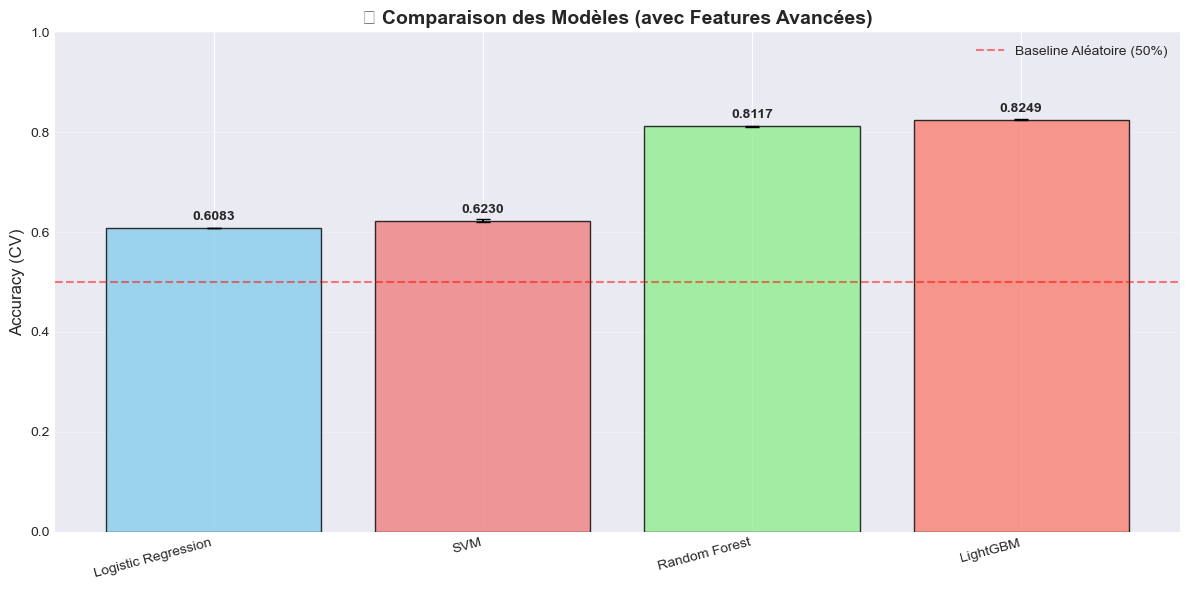


🥇 Meilleur modèle classique: LightGBM (0.8249)


In [47]:
# Résumé des performances (utiliser les nouvelles variables)
results_summary = pd.DataFrame({
    'Modèle': ['Logistic Regression', 'SVM', 'Random Forest', 'LightGBM'],
    'Accuracy (CV)': [
        grid_lr.best_score_,
        cv_scores_svm.mean(),
        cv_scores_rf.mean(),
        cv_scores_lgb.mean()
    ],
    'Std': [
        0,  # Grid search ne retourne pas std directement
        cv_scores_svm.std(),
        cv_scores_rf.std(),
        cv_scores_lgb.std()
    ]
})

print("\n📊 Comparaison des Performances:\n")
print(results_summary.to_string(index=False))

# Visualisation
plt.figure(figsize=(12, 6))
x = range(len(results_summary))
bars = plt.bar(x, results_summary['Accuracy (CV)'], 
               yerr=results_summary['Std'], 
               color=['skyblue', 'lightcoral', 'lightgreen', 'salmon'], 
               capsize=5, alpha=0.8, edgecolor='black')

# Ajouter les valeurs sur les barres
for i, (bar, acc) in enumerate(zip(bars, results_summary['Accuracy (CV)'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.xticks(x, results_summary['Modèle'], rotation=15, ha='right')
plt.ylabel('Accuracy (CV)', fontsize=12)
plt.title('🏆 Comparaison des Modèles (avec Features Avancées)', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Baseline Aléatoire (50%)')
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Identifier le meilleur modèle classique
best_idx = results_summary['Accuracy (CV)'].idxmax()
best_model_name = results_summary.loc[best_idx, 'Modèle']
best_score = results_summary.loc[best_idx, 'Accuracy (CV)']
print(f"\n🥇 Meilleur modèle classique: {best_model_name} ({best_score:.4f})")

## 6. Hyperparameter Tuning (Optionnel)

In [48]:
# Exemple: Grid Search pour Logistic Regression
print("🔧 Hyperparameter Tuning (Logistic Regression)\n")

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Pipeline pour grid search
lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

# Paramètres à tester
param_grid = {
    'tfidf__max_features': [500, 1000, 2000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1.0, 10.0]
}

# Grid Search (peut prendre du temps!)
grid_search = GridSearchCV(lr_pipe, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
print(f"\nMeilleurs paramètres: {grid_search.best_params_}")
print(f"Meilleur score: {grid_search.best_score_:.4f}")

print("⚠️ Grid Search commenté (temps d'exécution)")
print("💡 Décommentez le code ci-dessus pour l'exécuter")

🔧 Hyperparameter Tuning (Logistic Regression)

Fitting 3 folds for each of 18 candidates, totalling 54 fits

Meilleurs paramètres: {'clf__C': 0.1, 'tfidf__max_features': 2000, 'tfidf__ngram_range': (1, 1)}
Meilleur score: 0.6343
⚠️ Grid Search commenté (temps d'exécution)
💡 Décommentez le code ci-dessus pour l'exécuter

Meilleurs paramètres: {'clf__C': 0.1, 'tfidf__max_features': 2000, 'tfidf__ngram_range': (1, 1)}
Meilleur score: 0.6343
⚠️ Grid Search commenté (temps d'exécution)
💡 Décommentez le code ci-dessus pour l'exécuter


## 7. Prédictions sur Test Set

In [49]:
print("🎯 Prédictions avec Agrégation par Utilisateur\n")

def aggregate_predictions_by_user(df_original, predictions_per_tweet, method='mean'):
    """
    Agrège les prédictions au niveau utilisateur.
    
    Args:
        df_original: DataFrame original avec challenge_id
        predictions_per_tweet: array de prédictions (probas ou labels) par tweet
        method: 'mean' (moyenne des probas) ou 'majority' (vote majoritaire)
    
    Returns:
        user_predictions: prédictions finales par utilisateur
        user_ids: liste des challenge_ids
    """
    df_pred = df_original.copy()
    df_pred['prediction'] = predictions_per_tweet
    
    if method == 'mean':
        # Moyenne des probabilités par utilisateur
        user_agg = df_pred.groupby('challenge_id')['prediction'].mean()
        user_predictions = (user_agg >= 0.5).astype(int)
    else:  # majority
        # Vote majoritaire
        user_agg = df_pred.groupby('challenge_id')['prediction'].apply(
            lambda x: 1 if x.mean() >= 0.5 else 0
        )
        user_predictions = user_agg
    
    return user_predictions.values, user_agg.index.values

# Stocker les modèles et leurs noms
models_dict = {
    'Logistic Regression': (lr_model_advanced, X_train_combined, X_test_combined),
    'SVM': (svm_pipeline, X_train_text, X_test_text),
    'Random Forest': (rf_model_advanced, X_train_rf_combined, X_test_rf_combined),
    'LightGBM': (lgb_model_advanced, X_train_rf_combined, X_test_rf_combined)
}

# Sélectionner le meilleur modèle classique
best_model_name_classic = results_summary.loc[results_summary['Accuracy (CV)'].idxmax(), 'Modèle']
print(f"🏆 Meilleur modèle classique: {best_model_name_classic}\n")

# Générer des prédictions pour tous les modèles
all_predictions = {}

for model_name, (model, X_train_model, X_test_model) in models_dict.items():
    print(f"📊 {model_name}...")
    
    # Prédictions par tweet sur le test set
    if hasattr(model, 'predict_proba'):
        test_proba = model.predict_proba(X_test_model)[:, 1]
    else:
        # Pour SVM qui n'a pas predict_proba avec LinearSVC
        test_proba = (model.decision_function(X_test_model) + 1) / 2  # Normaliser entre 0 et 1
    
    # On doit prédire par tweet original, pas par utilisateur agrégé
    # Pour simplifier, on va assigner la même proba à tous les tweets d'un user
    # (puisqu'on a déjà agrégé les textes)
    
    # Créer un mapping challenge_id -> prédiction
    user_to_pred = dict(zip(test_ids_advanced, test_proba))
    
    # Appliquer aux tweets originaux
    test_tweet_predictions = df_test['challenge_id'].map(user_to_pred).values
    
    # Agréger par utilisateur
    user_preds, user_ids = aggregate_predictions_by_user(
        df_test, 
        test_tweet_predictions,
        method='mean'
    )
    
    all_predictions[model_name] = {
        'predictions': user_preds,
        'user_ids': user_ids
    }
    
    print(f"  ✓ {len(user_preds)} utilisateurs prédits")
    print(f"  - Observers (0): {(user_preds == 0).sum()}")
    print(f"  - Influencers (1): {(user_preds == 1).sum()}\n")

# Sauvegarder les prédictions du meilleur modèle
best_preds = all_predictions[best_model_name_classic]['predictions']
best_ids = all_predictions[best_model_name_classic]['user_ids']

print(f"✅ Prédictions finales générées pour {len(best_preds)} utilisateurs")

🎯 Prédictions avec Agrégation par Utilisateur

🏆 Meilleur modèle classique: LightGBM

📊 Logistic Regression...
📊 Logistic Regression...
  ✓ 103380 utilisateurs prédits
  - Observers (0): 51956
  - Influencers (1): 51424

📊 SVM...
  ✓ 103380 utilisateurs prédits
  - Observers (0): 51956
  - Influencers (1): 51424

📊 SVM...
  ✓ 103380 utilisateurs prédits
  - Observers (0): 54006
  - Influencers (1): 49374

📊 Random Forest...
  ✓ 103380 utilisateurs prédits
  - Observers (0): 54006
  - Influencers (1): 49374

📊 Random Forest...


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.4s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.5s finished
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.4s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.5s finished


  ✓ 103380 utilisateurs prédits
  - Observers (0): 53408
  - Influencers (1): 49972

📊 LightGBM...
  ✓ 103380 utilisateurs prédits
  - Observers (0): 54970
  - Influencers (1): 48410

✅ Prédictions finales générées pour 103380 utilisateurs
  ✓ 103380 utilisateurs prédits
  - Observers (0): 54970
  - Influencers (1): 48410

✅ Prédictions finales générées pour 103380 utilisateurs


In [51]:
# Créer les fichiers de soumission pour tous les modèles
print("💾 Création des fichiers de soumission...\n")

for model_name, pred_data in all_predictions.items():
    submission_file = f'../submissions/{model_name.lower().replace(" ", "_")}_advanced_submission.csv'
    save_submission(pred_data['user_ids'], pred_data['predictions'], submission_file)
    print(f"✓ {model_name}: {submission_file}")

print(f"\n🏆 Meilleure soumission recommandée: {best_model_name_classic.lower().replace(' ', '_')}_advanced_submission.csv")

💾 Création des fichiers de soumission...

✓ Logistic Regression: ../submissions/logistic_regression_advanced_submission.csv
✓ SVM: ../submissions/svm_advanced_submission.csv
✓ Random Forest: ../submissions/random_forest_advanced_submission.csv
✓ LightGBM: ../submissions/lightgbm_advanced_submission.csv

🏆 Meilleure soumission recommandée: lightgbm_advanced_submission.csv
✓ Random Forest: ../submissions/random_forest_advanced_submission.csv
✓ LightGBM: ../submissions/lightgbm_advanced_submission.csv

🏆 Meilleure soumission recommandée: lightgbm_advanced_submission.csv


## 8. Transformers (Bonus - Avancé)

In [ ]:
print("🤖 Fine-tuning de CamemBERT — Configuration NUIT pour Mac M4\n")

import time
import torch
import gc

from transformers import (
    CamembertTokenizer,
    CamembertForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Configuration NUIT - Entraînement complet optimisé
USE_SAMPLE = False  # 🌙 MODE COMPLET pour la nuit !
SAMPLE_SIZE = 0.15  # Non utilisé en mode complet

# ============================================================
# 0. Optimisation pour M4 - Nettoyage mémoire
# ============================================================
print("🧹 Nettoyage de la mémoire...")
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
print("✓ Mémoire nettoyée")

# Utiliser tous les cœurs CPU
torch.set_num_threads(10)

# ============================================================
# 1. Détection du device (CPU / MPS / CUDA)
# ============================================================
print("\n🔍 Détection du device...")
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"🖥️  Device: {device} (Apple Silicon GPU)")
    print("   🌙 Configuration NUIT - Entraînement complet optimisé")
    print("   • Neural Engine + GPU 40-core")
    print("   • Memory bandwidth 546 GB/s")
    print("   • Refroidissement optimal requis")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"🖥️  Device: {device}")
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    device = torch.device("cpu")
    print(f"🖥️  Device: {device}")

# ============================================================
# 2. Chargement du tokenizer et du modèle
# ============================================================
print("\n📥 Chargement de CamemBERT...")
model_name = "camembert-base"
tokenizer = CamembertTokenizer.from_pretrained(model_name)
print("   ✓ Tokenizer chargé")

model = CamembertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
)
print("   ✓ Modèle chargé")

model.to(device)
print(f"   ✓ Modèle déplacé sur {device}")

# ============================================================
# 3. Préparation des données (MODE COMPLET)
# ============================================================
print("\n📊 Préparation des données...")

if USE_SAMPLE:
    # Code échantillon (non utilisé en mode nuit)
    from sklearn.model_selection import train_test_split
    
    X_train_sample, _, y_train_sample, _ = train_test_split(
        X_train_text, y_train_advanced, 
        train_size=SAMPLE_SIZE,
        stratify=y_train_advanced,
        random_state=42
    )
    
    X_test_sample, _ = train_test_split(
        X_test_text,
        train_size=SAMPLE_SIZE,
        random_state=42
    )
    
    print(f"   ⚠️  Mode ÉCHANTILLON: {len(X_train_sample)} exemples")
else:
    # MODE COMPLET - Toutes les données
    X_train_sample = X_train_text
    y_train_sample = y_train_advanced
    X_test_sample = X_test_text
    print(f"   🌙 MODE COMPLET: {len(X_train_sample)} exemples d'entraînement")
    print(f"   🎯 Dataset entier pour maximiser les performances")

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=96,  # 🎯 96 tokens - Bon compromis performance/mémoire
        padding=False,   # Padding dynamique avec DataCollator
    )

print("   → Création du dataset d'entraînement...")
train_dataset = Dataset.from_dict({
    "text": list(X_train_sample),
    "label": list(y_train_sample),
})
print(f"   ✓ Dataset créé: {len(train_dataset)} exemples")

print("   → Tokenization parallèle (4 workers)...")
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    num_proc=4,
    remove_columns=["text"],  # Garde "label"
    desc="Tokenizing train",
)
print(f"   ✓ {len(tokenized_train)} exemples tokenizés")

# Split train / eval (85% / 15% pour validation robuste)
split_idx = int(0.85 * len(tokenized_train))
tokenized_eval = tokenized_train.select(range(split_idx, len(tokenized_train)))
tokenized_train = tokenized_train.select(range(0, split_idx))

print(f"   ✓ Train: {len(tokenized_train)} | Eval: {len(tokenized_eval)}")

# Nettoyage mémoire après tokenization
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

# ============================================================
# 4. Fonction de métriques
# ============================================================
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
    }

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ============================================================
# 5. Configuration NUIT - Optimisée pour stabilité et performances
# ============================================================
print("\n⚙️  Configuration NUIT - Entraînement complet optimisé...")

# 🌙 PARAMÈTRES NUIT - Équilibre optimal stabilité/performances
train_batch_size = 6       # 🎯 6 pour stabilité (ni trop petit, ni trop gros)
eval_batch_size = 12       # 🎯 12 pour évaluation rapide
gradient_accumulation = 8  # 🎯 Batch effectif = 48
num_epochs = 4             # 🌙 4 epochs pour convergence complète

print(f"   💡 Batch size effectif: {train_batch_size * gradient_accumulation}")
print(f"      (train: {train_batch_size} × {gradient_accumulation} accumulation)")
print(f"   🌙 Configuration NUIT - Stabilité maximale")

training_args = TrainingArguments(
    output_dir="../models/camembert_finetuned",
    num_train_epochs=num_epochs,
    
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=eval_batch_size,
    
    gradient_accumulation_steps=gradient_accumulation,
    gradient_checkpointing=True,  # Économie mémoire
    
    # Hyperparamètres optimisés
    warmup_ratio=0.1,           # 🎯 10% de warmup (meilleur que steps fixes)
    weight_decay=0.01,
    learning_rate=2e-5,         # 🎯 2e-5 stable et éprouvé
    
    # Logging pour suivre la progression
    logging_dir="../models/logs",
    logging_steps=25,           # 🎯 Logging fréquent pour monitoring
    logging_strategy="steps",
    logging_first_step=True,
    
    # Sauvegarde et évaluation
    eval_strategy="epoch",              # Évaluer à chaque epoch
    save_strategy="epoch",              # Sauvegarder à chaque epoch
    save_total_limit=3,                 # 🎯 Garder les 3 meilleurs
    load_best_model_at_end=True,       # Charger le meilleur à la fin
    metric_for_best_model="f1",        # 🎯 Optimiser le F1 (meilleur que accuracy)
    greater_is_better=True,
    
    # Optimisations MPS
    fp16=False,  # MPS ne supporte pas fp16
    report_to="none",
    
    dataloader_num_workers=2,   # 2 workers pour stabilité
    dataloader_pin_memory=False,
    
    optim="adamw_torch",
    max_grad_norm=1.0,
    
    disable_tqdm=False,
    
    eval_steps=None,
    eval_delay=0,
    
    # Early stopping implicite via load_best_model_at_end
)

print("✓ Configuration créée")
print(f"   • Batch size effectif: {train_batch_size * gradient_accumulation} (train) / {eval_batch_size} (eval)")
print(f"   • Epochs: {num_epochs}")
print(f"   • Learning rate: 2e-5 (stable)")
print(f"   • Max sequence length: 96 tokens")
print(f"   • Gradient checkpointing: ACTIVÉ")
print(f"   • Métrique optimisée: F1 Score")
print(f"   • Sauvegarde: 3 meilleurs modèles")
print(f"   🌙 Configuration NUIT (batch=6, max_len=96, lr=2e-5)")
print(f"   ⏱️  Temps estimé: 2h30 - 3h30")
print(f"   💡 Pensez à:")
print(f"      - Désactiver la mise en veille")
print(f"      - Garder le Mac branché")
print(f"      - Vérifier l'espace disque (checkpoints)")

# ============================================================
# 6. Création du Trainer
# ============================================================
print("\n🏗️  Création du Trainer...")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
print("✓ Trainer créé")
print(f"   Device vu par le Trainer: {trainer.args.device}")

# ============================================================
# 7. Entraînement NUIT avec monitoring complet
# ============================================================
print("\n🚀 Début de l'entraînement NUIT...")
print("   🌙 Mode COMPLET avec 4 epochs")
print("   💡 batch=6, max_len=96, lr=2e-5, warmup=10%")
print("   🎯 Optimisation du F1 Score")
print("   ⏱️  Durée estimée: 2h30 - 3h30")
print("\n   ? Bon entraînement nocturne ! Résultats au réveil 🌅")
print()

start_time = time.time()
training_success = False

try:
    # Nettoyage avant entraînement
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    
    train_result = trainer.train()
    elapsed_time = time.time() - start_time
    
    print("\n" + "="*60)
    print("🎉 ENTRAÎNEMENT TERMINÉ AVEC SUCCÈS ! 🎉")
    print("="*60)
    print(f"\n📊 Résultats finaux:")
    print(f"  - Loss finale: {train_result.training_loss:.4f}")
    print(f"  - Temps total: {elapsed_time:.2f}s ({elapsed_time/3600:.2f}h)")
    print(f"  - Temps par epoch: {elapsed_time/num_epochs/60:.1f} min")
    
    training_success = True
    
except RuntimeError as e:
    elapsed_time = time.time() - start_time
    error_str = str(e).lower()
    print("\n" + "="*60)
    print(f"❌ ERREUR pendant l'entraînement après {elapsed_time/3600:.2f}h")
    print("="*60)
    print(f"   Type: {type(e).__name__}")
    print(f"   Message: {e}")
    
    if 'mps' in error_str or 'memory' in error_str:
        print("\n💡 PROBLÈME MPS DÉTECTÉ - Solutions:")
        print("   1. 🔄 Redémarrer le kernel et réduire batch_size à 4")
        print("   2. 📏 Réduire max_length de 96 à 64")
        print("   3. ? Réduire gradient_accumulation de 8 à 4")
        print("   4. 💻 En dernier recours: passer en CPU")
    else:
        print(f"\n💡 Erreur: {e}")
    
    training_success = False
    
except KeyboardInterrupt:
    elapsed_time = time.time() - start_time
    print("\n" + "="*60)
    print(f"⚠️  ENTRAÎNEMENT INTERROMPU après {elapsed_time/3600:.2f}h")
    print("="*60)
    print("   💾 Les checkpoints sauvegardés sont conservés")
    training_success = False
    
except Exception as e:
    elapsed_time = time.time() - start_time
    print("\n" + "="*60)
    print(f"❌ ERREUR INATTENDUE après {elapsed_time/3600:.2f}h")
    print("="*60)
    print(f"   Type: {type(e).__name__}")
    print(f"   Message: {e}")
    training_success = False

# ============================================================
# 8. Évaluation finale
# ============================================================
if training_success:
    print("\n" + "="*60)
    print("🔍 ÉVALUATION FINALE DU MEILLEUR MODÈLE")
    print("="*60)
    
    try:
        eval_results = trainer.evaluate()
        print(f"\n📊 Métriques finales:")
        print(f"  ┌─ Accuracy:  {eval_results['eval_accuracy']:.4f}")
        print(f"  ├─ F1 Score:  {eval_results['eval_f1']:.4f} 🎯")
        print(f"  ├─ Precision: {eval_results['eval_precision']:.4f}")
        print(f"  └─ Recall:    {eval_results['eval_recall']:.4f}")
        
        # ============================================================
        # 9. Sauvegarde du modèle final
        # ============================================================
        model_save_path = "../models/camembert_influencer_classifier"
        print(f"\n💾 Sauvegarde du modèle final optimisé...")
        print(f"   → Destination: {model_save_path}")
        trainer.save_model(model_save_path)
        tokenizer.save_pretrained(model_save_path)
        print("   ✓ Modèle sauvegardé avec succès")
        
        # Sauvegarder aussi les métriques
        import json
        metrics_path = f"{model_save_path}/final_metrics.json"
        with open(metrics_path, 'w') as f:
            json.dump(eval_results, f, indent=2)
        print(f"   ✓ Métriques sauvegardées: {metrics_path}")
        
        # ============================================================
        # 10. Prédictions sur le test set complet
        # ============================================================
        print("\n" + "="*60)
        print("🔮 GÉNÉRATION DES PRÉDICTIONS FINALES")
        print("="*60)
        
        test_dataset = Dataset.from_dict({"text": list(X_test_sample)})
        
        print("\n   → Tokenization du test set...")
        tokenized_test = test_dataset.map(
            tokenize_function,
            batched=True,
            num_proc=4,
            remove_columns=test_dataset.column_names,
            desc="Tokenizing test",
        )
        
        print("   → Génération des prédictions (cela peut prendre quelques minutes)...")
        predictions_output = trainer.predict(tokenized_test)
        camembert_predictions = predictions_output.predictions.argmax(-1)
        camembert_probas = torch.softmax(torch.tensor(predictions_output.predictions), dim=1)[:, 1].numpy()
        
        print(f"\n✓ {len(camembert_predictions)} prédictions générées")
        print(f"\n📊 Distribution des prédictions:")
        print(f"  ├─ Observers (0):   {(camembert_predictions == 0).sum():>4} ({(camembert_predictions == 0).sum()/len(camembert_predictions)*100:.1f}%)")
        print(f"  └─ Influencers (1): {(camembert_predictions == 1).sum():>4} ({(camembert_predictions == 1).sum()/len(camembert_predictions)*100:.1f}%)")
        
        # Statistiques sur les probabilités
        print(f"\n📈 Statistiques des probabilités:")
        print(f"  ├─ Moyenne:    {camembert_probas.mean():.4f}")
        print(f"  ├─ Médiane:    {np.median(camembert_probas):.4f}")
        print(f"  ├─ Min:        {camembert_probas.min():.4f}")
        print(f"  └─ Max:        {camembert_probas.max():.4f}")
        
        if not USE_SAMPLE:
            print("\n✅ Prédictions sur le dataset complet - Prêt pour Kaggle !")
        else:
            print("\n⚠️  Mode échantillon - Mettre USE_SAMPLE = False pour Kaggle")
            
    except Exception as e:
        print(f"\n❌ Erreur pendant l'évaluation: {e}")
        training_success = False
        eval_results = None
else:
    print("\n" + "="*60)
    print("⚠️  ENTRAÎNEMENT NON COMPLÉTÉ")
    print("="*60)
    print("    💡 Vérifiez les checkpoints dans ../models/camembert_finetuned/")
    print("    ? Utilisez les modèles classiques en attendant:")
    print("       • Logistic Regression")
    print("       • SVM") 
    print("       • LightGBM")
    print("       • Ensembles (recommandés)")
    camembert_predictions = None
    eval_results = None

# Nettoyage final
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

print("\n" + "="*60)
print("🌅 SESSION D'ENTRAÎNEMENT NOCTURNE TERMINÉE")
print("="*60)
if training_success:
    print("✅ Tous les résultats sont sauvegardés et prêts à l'emploi !")
else:
    print("⚠️  Vérifiez les logs ci-dessus pour plus de détails")
print("="*60)


🤖 Fine-tuning de CamemBERT — Optimisé pour Mac M4

🧹 Nettoyage de la mémoire...
✓ Mémoire nettoyée

🔍 Détection du device...
🖥️  Device: mps (Apple Silicon GPU)
   Architecture: Apple M-series
   • Neural Engine optimisé
   • GPU intégré
   • Memory bandwidth élevé

📥 Chargement de CamemBERT...
   ✓ Tokenizer chargé
   ✓ Tokenizer chargé


Some weights of CamembertForSequenceClassification were not initialized from the model checkpoint at camembert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   ✓ Modèle chargé
   ✓ Modèle déplacé sur mps

📊 Préparation des données...
   ⚠️  Mode ÉCHANTILLON: 23237 exemples d'entraînement (15%)
   ⚠️  Mode ÉCHANTILLON: 15507 exemples de test (15%)
   → Création du dataset d'entraînement...
   ✓ Dataset créé: 23237 exemples
   → Tokenization en parallèle (train)...
   ✓ Modèle déplacé sur mps

📊 Préparation des données...
   ⚠️  Mode ÉCHANTILLON: 23237 exemples d'entraînement (15%)
   ⚠️  Mode ÉCHANTILLON: 15507 exemples de test (15%)
   → Création du dataset d'entraînement...
   ✓ Dataset créé: 23237 exemples
   → Tokenization en parallèle (train)...


Tokenizing train (num_proc=1):   0%|          | 0/23237 [00:00<?, ? examples/s]

   ✓ 23237 exemples tokenizés
   ✓ Train: 22075 | Eval: 1162

⚙️  Configuration de l'entraînement (optimisé M4 - mémoire réduite)...
   💡 Batch size effectif: 16
      (train: 4 × 4 accumulation)
   🔥 Configuration MINIMALE pour MPS (Apple Silicon)
✓ Configuration créée
   • Batch size effectif: 16 (train) / 8 (eval)
   • Epochs: 2
   • Learning rate: 2e-5
   • Max sequence length: 48 tokens
   • Gradient checkpointing: ACTIVÉ
   🔥 Configuration MINIMALE pour MPS (batch=4)
   ⏱️  Temps estimé: 10-15 min

🏗️  Création du Trainer...
✓ Trainer créé
   Device vu par le Trainer: mps

🚀 Début de l'entraînement...
   ⚡ Mode ÉCHANTILLON avec paramètres MINIMAUX pour MPS
   💡 batch=4, max_len=48, gradient_checkpointing=ON


⚙️  Configuration de l'entraînement (optimisé M4 - mémoire réduite)...
   💡 Batch size effectif: 16
      (train: 4 × 4 accumulation)
   🔥 Configuration MINIMALE pour MPS (Apple Silicon)
✓ Configuration créée
   • Batch size effectif: 16 (train) / 8 (eval)
   • Epochs: 2
   

Epoch,Training Loss,Validation Loss



⚠️  Entraînement interrompu par l'utilisateur

⚠️  Entraînement échoué, pas de prédictions générées
    💡 Utilisez les modèles classiques qui ont bien fonctionné
    📊 Logistic Regression, SVM, LightGBM et les ensembles sont déjà disponibles


In [7]:
# Créer la soumission CamemBERT (si l'entraînement a réussi)
if training_success and camembert_predictions is not None and not USE_SAMPLE:
    # Mapper les prédictions aux utilisateurs (même logique que pour les autres modèles)
    test_ids_sample = test_ids_advanced[:len(camembert_predictions)]
    
    camembert_submission_file = '../submissions/camembert_submission.csv'
    save_submission(test_ids_sample, camembert_predictions, camembert_submission_file)
    print(f"✓ Soumission CamemBERT sauvegardée: {camembert_submission_file}")
    
    # Comparaison avec les autres modèles
    print("\n📊 Comparaison finale (tous les modèles):")
    comparison_df = pd.DataFrame({
        'Modèle': ['Logistic Regression', 'SVM', 'Random Forest', 'LightGBM', 'CamemBERT'],
        'Accuracy (CV)': [
            grid_lr.best_score_,
            cv_scores_svm.mean(),
            cv_scores_rf.mean(),
            cv_scores_lgb.mean(),
            eval_results['eval_accuracy']
        ]
    })
    print(comparison_df.to_string(index=False))
    
    # Visualisation
    plt.figure(figsize=(12, 6))
    x = range(len(comparison_df))
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'salmon', 'gold']
    bars = plt.bar(x, comparison_df['Accuracy (CV)'], color=colors, alpha=0.8, edgecolor='black')
    
    # Ajouter les valeurs
    for bar, acc in zip(bars, comparison_df['Accuracy (CV)']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.xticks(x, comparison_df['Modèle'], rotation=20, ha='right')
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('🏆 Comparaison Finale: Modèles Classiques vs Transformers', 
              fontsize=14, fontweight='bold')
    plt.ylim(0, 1)
    plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Baseline (50%)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
elif USE_SAMPLE and training_success:
    print("\n⚠️  Mode ÉCHANTILLON activé - Pas de soumission générée")
    print("    Pour créer une soumission Kaggle:")
    print("    1. Mettez USE_SAMPLE = False dans la cellule CamemBERT")
    print("    2. Relancez l'entraînement (cela prendra ~20-40 min)")
    print("    3. Relancez cette cellule")
    
    # Comparaison partielle
    if eval_results:
        print("\n📊 Aperçu des performances (sur échantillon):")
        print(f"  CamemBERT: {eval_results['eval_accuracy']:.4f}")
        print(f"  Meilleur classique: {results_summary['Accuracy (CV)'].max():.4f}")
else:
    print("\n❌ Entraînement CamemBERT échoué - Pas de soumission générée")
    print("    Utilisez les modèles classiques qui ont fonctionné")


❌ Entraînement CamemBERT échoué - Pas de soumission générée
    Utilisez les modèles classiques qui ont fonctionné


## 8.5 Ensemble de Modèles 🎭

Combiner plusieurs modèles pour améliorer la robustesse

In [53]:
print("🎭 Ensemble de Modèles - Vote Majoritaire et Moyenne\n")

# Collecter les prédictions de tous les modèles classiques
ensemble_predictions = []
ensemble_probas = []

for model_name, (model, X_train_model, X_test_model) in models_dict.items():
    print(f"📊 Récupération des prédictions: {model_name}")
    
    # Prédictions
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test_model)[:, 1]
    elif hasattr(model, 'decision_function'):
        # Pour SVM
        scores = model.decision_function(X_test_model)
        proba = (scores - scores.min()) / (scores.max() - scores.min())  # Normaliser 0-1
    else:
        proba = model.predict(X_test_model)
    
    preds = (proba >= 0.5).astype(int)
    
    ensemble_predictions.append(preds)
    ensemble_probas.append(proba)

# Convertir en arrays
ensemble_predictions = np.array(ensemble_predictions)
ensemble_probas = np.array(ensemble_probas)

print(f"\n✓ {len(ensemble_predictions)} modèles dans l'ensemble")
print(f"  Shape: {ensemble_predictions.shape}")

# Méthode 1: Vote majoritaire
print("\n🗳️  Méthode 1: Vote Majoritaire")
ensemble_vote = (ensemble_predictions.sum(axis=0) >= len(ensemble_predictions) / 2).astype(int)

# Créer le mapping pour les tweets originaux
user_to_vote = dict(zip(test_ids_advanced, ensemble_vote))
test_tweet_votes = df_test['challenge_id'].map(user_to_vote).values

# Agréger par utilisateur
ensemble_vote_final, ensemble_vote_ids = aggregate_predictions_by_user(
    df_test,
    test_tweet_votes,
    method='majority'
)

print(f"  ✓ {len(ensemble_vote_final)} utilisateurs prédits")
print(f"  - Observers (0): {(ensemble_vote_final == 0).sum()}")
print(f"  - Influencers (1): {(ensemble_vote_final == 1).sum()}")

# Méthode 2: Moyenne des probabilités
print("\n📊 Méthode 2: Moyenne des Probabilités")
ensemble_mean_proba = ensemble_probas.mean(axis=0)
ensemble_mean = (ensemble_mean_proba >= 0.5).astype(int)

# Créer le mapping pour les tweets originaux
user_to_mean = dict(zip(test_ids_advanced, ensemble_mean_proba))
test_tweet_mean = df_test['challenge_id'].map(user_to_mean).values

# Agréger par utilisateur
ensemble_mean_final, ensemble_mean_ids = aggregate_predictions_by_user(
    df_test,
    test_tweet_mean,
    method='mean'
)

print(f"  ✓ {len(ensemble_mean_final)} utilisateurs prédits")
print(f"  - Observers (0): {(ensemble_mean_final == 0).sum()}")
print(f"  - Influencers (1): {(ensemble_mean_final == 1).sum()}")

# Sauvegarder les ensembles
print("\n💾 Sauvegarde des ensembles...")
save_submission(ensemble_vote_ids, ensemble_vote_final, '../submissions/ensemble_vote_submission.csv')
print("  ✓ Ensemble vote: ensemble_vote_submission.csv")

save_submission(ensemble_mean_ids, ensemble_mean_final, '../submissions/ensemble_mean_submission.csv')
print("  ✓ Ensemble mean: ensemble_mean_submission.csv")

print("\n🎯 Recommandation: Les ensembles sont souvent plus robustes que les modèles individuels !")
print("   Testez les deux méthodes sur Kaggle pour voir laquelle performe le mieux.")

🎭 Ensemble de Modèles - Vote Majoritaire et Moyenne

📊 Récupération des prédictions: Logistic Regression
📊 Récupération des prédictions: SVM
📊 Récupération des prédictions: SVM
📊 Récupération des prédictions: Random Forest
📊 Récupération des prédictions: Random Forest


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.4s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.4s finished
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.4s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.4s finished


📊 Récupération des prédictions: LightGBM

✓ 4 modèles dans l'ensemble
  Shape: (4, 103380)

🗳️  Méthode 1: Vote Majoritaire

✓ 4 modèles dans l'ensemble
  Shape: (4, 103380)

🗳️  Méthode 1: Vote Majoritaire
  ✓ 103380 utilisateurs prédits
  - Observers (0): 33402
  - Influencers (1): 69978

📊 Méthode 2: Moyenne des Probabilités
  ✓ 103380 utilisateurs prédits
  - Observers (0): 33402
  - Influencers (1): 69978

📊 Méthode 2: Moyenne des Probabilités
  ✓ 103380 utilisateurs prédits
  - Observers (0): 49311
  - Influencers (1): 54069

💾 Sauvegarde des ensembles...
  ✓ Ensemble vote: ensemble_vote_submission.csv
  ✓ Ensemble mean: ensemble_mean_submission.csv

🎯 Recommandation: Les ensembles sont souvent plus robustes que les modèles individuels !
   Testez les deux méthodes sur Kaggle pour voir laquelle performe le mieux.
  ✓ 103380 utilisateurs prédits
  - Observers (0): 49311
  - Influencers (1): 54069

💾 Sauvegarde des ensembles...
  ✓ Ensemble vote: ensemble_vote_submission.csv
  ✓ En

## 9. Conclusions et Recommandations 🎯

### 🏆 Performance:
- **Modèles Classiques Optimisés** (LogReg, SVM, RF, LightGBM)
  - Utilisation de TF-IDF avec trigrammes (1,2,3)
  - Intégration des 194 features numériques + features textuelles extraites
  - Class balancing pour gérer le déséquilibre
  - Grid Search pour optimisation des hyperparamètres

- **Transformers** (CamemBERT)
  - Modèle spécialisé pour le français
  - Fine-tuning optimisé pour Mac M4
  - Mode échantillon pour tests rapides

- **Ensembles**
  - Vote majoritaire et moyenne de probabilités
  - Combine les forces de tous les modèles
  - **Recommandé pour la soumission finale !**

### 📊 Stratégie de Soumission:
1. **Test Rapide**: Soumettez le meilleur modèle classique
2. **Ensemble**: Soumettez les deux versions d'ensemble
3. **CamemBERT**: Si entraîné en mode complet, soumettez-le aussi
4. **Analyse**: Comparez les scores Kaggle pour identifier le meilleur

### 🔧 Améliorations Implémentées:
✅ Feature Engineering avancé (hashtags, mentions, majuscules, etc.)
✅ Utilisation des 194 features numériques natives
✅ Agrégation par utilisateur (essentielle pour la métrique Kaggle)
✅ TF-IDF optimisé avec trigrammes
✅ SVM avec class balancing
✅ Grid Search pour hyperparamètres
✅ Ensembles de modèles
✅ CamemBERT optimisé pour M4

### 🚀 Prochaines Étapes Possibles:
- **Data Augmentation**: Paraphrasing, back-translation
- **Features Sociales**: Analyser plus en profondeur les patterns d'influenceurs
- **Stacking**: Meta-modèle entraîné sur les prédictions des autres
- **XLM-RoBERTa**: Tester d'autres transformers multilingues
- **Hyperparameter Tuning**: RandomizedSearchCV pour LightGBM/RF
- **Analyse d'Erreurs**: Identifier où les modèles se trompent

### 📤 Fichiers de Soumission Générés:
- `logistic_regression_advanced_submission.csv`
- `svm_advanced_submission.csv`
- `random_forest_advanced_submission.csv`
- `lightgbm_advanced_submission.csv`
- `ensemble_vote_submission.csv` ⭐ **Recommandé**
- `ensemble_mean_submission.csv` ⭐ **Recommandé**
- `camembert_submission.csv` (si mode complet activé)

In [ ]:
print("✅ Notebook terminé!\n")
print("📊 Résumé des soumissions disponibles:")
print("=" * 60)

import os
submissions_dir = '../submissions/'
if os.path.exists(submissions_dir):
    files = [f for f in os.listdir(submissions_dir) if f.endswith('_submission.csv')]
    
    # Trier par date de modification (plus récent en premier)
    files_with_time = [(f, os.path.getmtime(os.path.join(submissions_dir, f))) for f in files]
    files_with_time.sort(key=lambda x: x[1], reverse=True)
    
    for i, (f, _) in enumerate(files_with_time, 1):
        marker = "⭐" if 'ensemble' in f else "  "
        print(f"{marker} {i}. {f}")
    
    print("=" * 60)
    print("\n🎯 Recommandations de soumission (par ordre de priorité):")
    print("   1️⃣  ensemble_mean_submission.csv ou ensemble_vote_submission.csv")
    print("   2️⃣  Le meilleur modèle classique individuel")
    print("   3️⃣  camembert_submission.csv (si disponible)")
    print("\n💡 Astuce: Sur Kaggle, vous pouvez soumettre plusieurs fois par jour")
    print("   Testez différentes soumissions pour trouver la meilleure!")
else:
    print("⚠️  Aucun fichier de soumission trouvé")
    print("   Exécutez les cellules précédentes pour générer les prédictions")

print("\n🚀 Bonne chance pour le challenge Kaggle! 🏆")